In [1]:
%matplotlib ipympl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import Image, display, Math
import pickle
import os

In [ ]:

# ============
# ANGLE SETUP
# ============
theta_deg = 0

# ==========================
# Setup and Data Loading
# ==========================

# --- Time Step and Trajectory String Formatting ---
dt = 0.01
N_traj = 10000

dt_str = f"{dt:.6f}".replace(".", "p")
phi_str = f"{theta_deg:.4f}".replace(".", "p")

# --- Results Directory and Output Setup ---
results_dir = "../../Results/Data/Complete_rho/"

# Create a specific subfolder for the current angle (e.g., Plot/Populations/180)
Output_dir = f"../../Results/Plot/Populations/{phi_str}"
os.makedirs(Output_dir, exist_ok=True)


# Dynamically load the correct data file based on the angle
fname = os.path.join(results_dir, f"result_phi{phi_str}_dt{dt_str}_Ntraj{N_traj}.npz")

try:
    data = np.load(fname)
    print(f"Data extraction completed successfully for Theta = {theta_deg}°")
except FileNotFoundError:
    print(f"Error: File {fname} not found. Ensure the simulation for this angle has completed.")

print("Data extraction completed")



Data extraction completed successfully for Theta = 0.7°
Data extraction completed


In [3]:
times = data['times']
total_jumps = data['total_jumps']

# -----------------------------------------------
# Extract from rho_tot_all (3, 3, n_times, N_traj)
# -----------------------------------------------
rho_all = data['rho_tot_all']

# Populations
pop_00 = np.real(rho_all[0, 0, :, :])
pop_11 = np.real(rho_all[1, 1, :, :])
pop_22 = np.real(rho_all[2, 2, :, :])

# Coherences
coh_01 = rho_all[0, 1, :, :]
coh_12 = rho_all[1, 2, :, :]
coh_02 = rho_all[0, 2, :, :]

# Averages over all trajectories
avg_pop_00 = pop_00.mean(axis=1)
avg_pop_11 = pop_11.mean(axis=1)
avg_pop_22 = pop_22.mean(axis=1)
avg_coh_01 = coh_01.mean(axis=1)
avg_coh_12 = coh_12.mean(axis=1)
avg_coh_02 = coh_02.mean(axis=1)

# -----------------------------------------------
# Extract baseline: rho_trace (3, 3, n_times)
# -----------------------------------------------
rho_trace = data['rho_trace']
pops_trace_00 = np.real(rho_trace[0, 0, :])
pops_trace_11 = np.real(rho_trace[1, 1, :])
pops_trace_22 = np.real(rho_trace[2, 2, :])

# ----------------------------------------------------
# Extract Lindblad: rho_list_lindblad (n_times, 3, 3)
# ----------------------------------------------------
rho_lind = data['rho_list_lindblad']
lindblad_00 = np.real(rho_lind[:, 0, 0])
lindblad_11 = np.real(rho_lind[:, 1, 1])
lindblad_22 = np.real(rho_lind[:, 2, 2])
lindblad_12 = rho_lind[:, 1, 2]
lindblad_01 = rho_lind[:, 0, 1]
lindblad_02 = rho_lind[:, 0, 2]

# -----------------------------------------------
# Extract isolated system: rho_traj_isolated 
# -----------------------------------------------
rho_iso = data['rho_traj_isolated']
pop_traj_isolated_00 = np.real(rho_iso[0, 0, :])
pop_traj_isolated_11 = np.real(rho_iso[1, 1, :])
pop_traj_isolated_22 = np.real(rho_iso[2, 2, :])


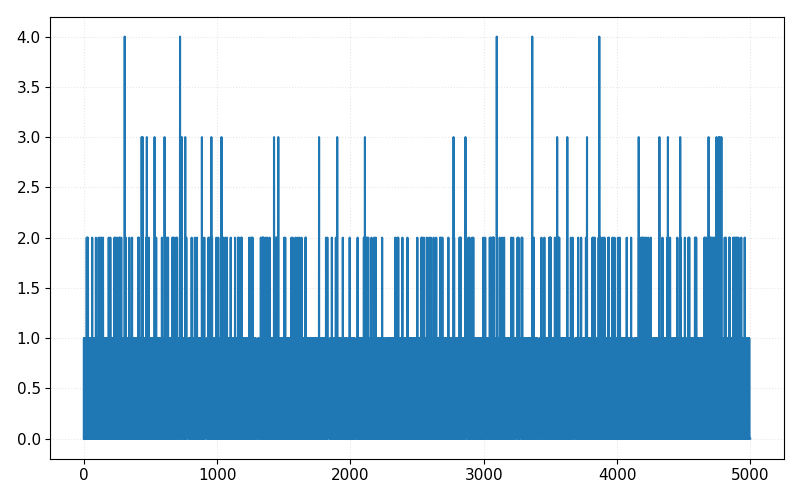

In [15]:
plt.close('all')
plt.plot(total_jumps)
plt.show()  

In [4]:
# ===========================
# General Setup for Plotting
# ===========================
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'figure.autolayout': True 
})

def save_fig(fig, filename):
    """Saves the figure cleanly without requiring a display output"""
    path_png = os.path.join(Output_dir, f"{filename}.png")
    fig.savefig(path_png, dpi=300, bbox_inches='tight')
    print(f"Saved: {path_png}")
    plt.close(fig)


In [5]:

# =========================================================
# Find trajectories that experienced a Quantum Jump
# =========================================================
# pop_11_diff = np.diff(pop_11, axis=0)
# jump_mask = np.any(np.abs(pop_11_diff) > 0.2, axis=0)
# jump_indices = np.where(jump_mask)[0]

# print(f"Total trajectories evaluated: {pop_11.shape[1]}")
# print(f"Found {len(jump_indices)} trajectories with jumps. Indices of jump trajectories: {jump_indices}")

# if len(jump_indices) > 0:
#     sample_idx = jump_indices[0]  
# else:
#     sample_idx = 0  # Fallback
# print(f"Selected sample_idx for plotting: {sample_idx}")

# =========================================================
# Find trajectories that experienced a Quantum Jump (Dynamic)
# =========================================================
pop_11_diff = np.diff(pop_11, axis=0)

# Calcola la fluttuazione standard dei cambiamenti in tutto l'ensemble
std_diff = np.std(pop_11_diff)

# Imposta una soglia dinamica (es. 5 deviazioni standard)
dynamic_threshold = 5 * std_diff

jump_mask = np.any(np.abs(pop_11_diff) > dynamic_threshold, axis=0)
jump_indices = np.where(jump_mask)[0]

print(f"Soglia dinamica calcolata: {dynamic_threshold:.6f}")
print(f"Total trajectories evaluated: {pop_11.shape[1]}")
print(f"Found {len(jump_indices)} trajectories with jumps.")

if len(jump_indices) > 0:
    sample_idx = jump_indices[0]  
else:
    sample_idx = 0  # Fallback
print(f"Selected sample_idx for plotting: {sample_idx}")

Soglia dinamica calcolata: 0.000259
Total trajectories evaluated: 10000
Found 1588 trajectories with jumps.
Selected sample_idx for plotting: 1


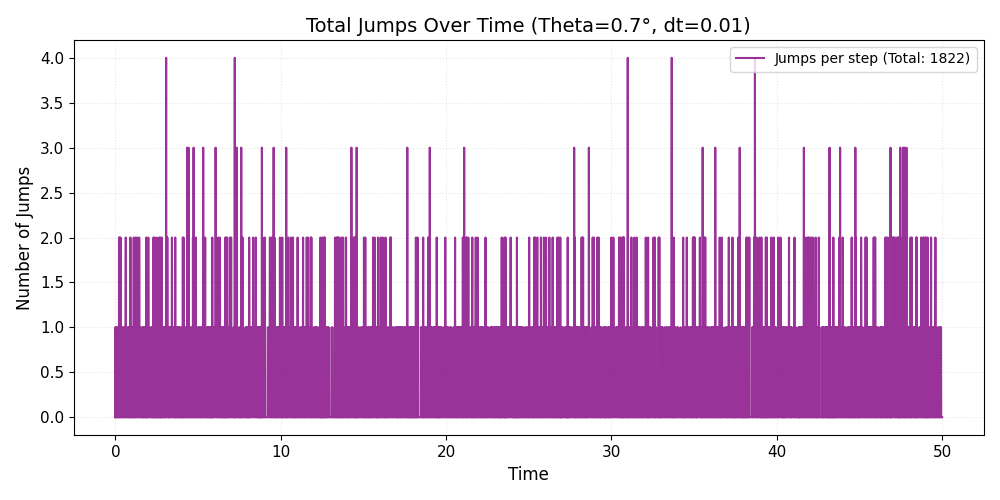

In [6]:
# ==========================================
# Plot 0: Plotting the Total Jump Counts
# ==========================================
fig_jumps, ax_jumps = plt.subplots(figsize=(10, 5))
ax_jumps.plot(times, total_jumps, color='purple', alpha=0.8, linewidth=1.5, 
              label=f'Jumps per step (Total: {np.sum(total_jumps)})')

ax_jumps.set_title(f"Total Jumps Over Time (Theta={theta_deg}°, dt={dt})", fontsize=14)
ax_jumps.set_xlabel("Time", fontsize=12)
ax_jumps.set_ylabel("Number of Jumps", fontsize=12)
ax_jumps.legend(loc='upper right')

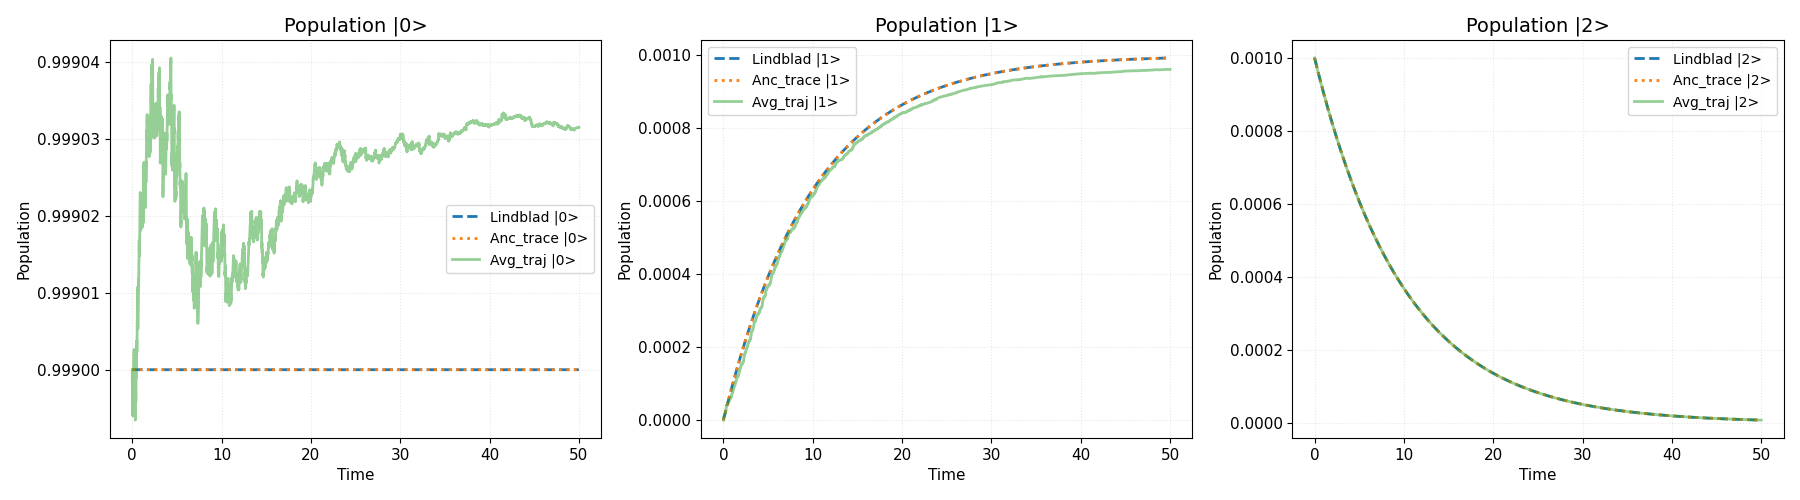

In [7]:
# ====================================
# Plot 1: Convergence Avg vs Trace vs Lindblad
# ====================================
populations = [
    {'lindblad': lindblad_00, 'trace': pops_trace_00, 'avg': avg_pop_00, 'label': '|0>'},
    {'lindblad': lindblad_11, 'trace': pops_trace_11, 'avg': avg_pop_11, 'label': '|1>'},
    {'lindblad': lindblad_22, 'trace': pops_trace_22, 'avg': avg_pop_22, 'label': '|2>'},
]

fig01, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, pop in zip(axes, populations):
    lbl = pop['label']
    ax.plot(times, pop['lindblad'], label=f'Lindblad {lbl}', linewidth=2, linestyle='--')
    ax.plot(times, pop['trace'],    label=f'Anc_trace {lbl}', linewidth=2, linestyle=':')
    ax.plot(times, pop['avg'],      label=f'Avg_traj {lbl}',  linewidth=2, alpha=0.5)

    ax.set_title(f'Population {lbl}', fontsize=14)
    ax.set_xlabel('Time')
    ax.set_ylabel('Population')

    formatter = ticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    ax.yaxis.set_major_formatter(formatter)
    ax.legend(loc='best')

plt.show()

# fig01.suptitle(f'Angle {theta_deg}° — Lindblad vs Trace vs Avg Traj | dt={dt}, N_traj={N_traj}', fontsize=15)
# save_fig(fig01, f'Comparison_3pop_Theta_{float(theta_deg):.4f}'.replace('.', 'p')) 


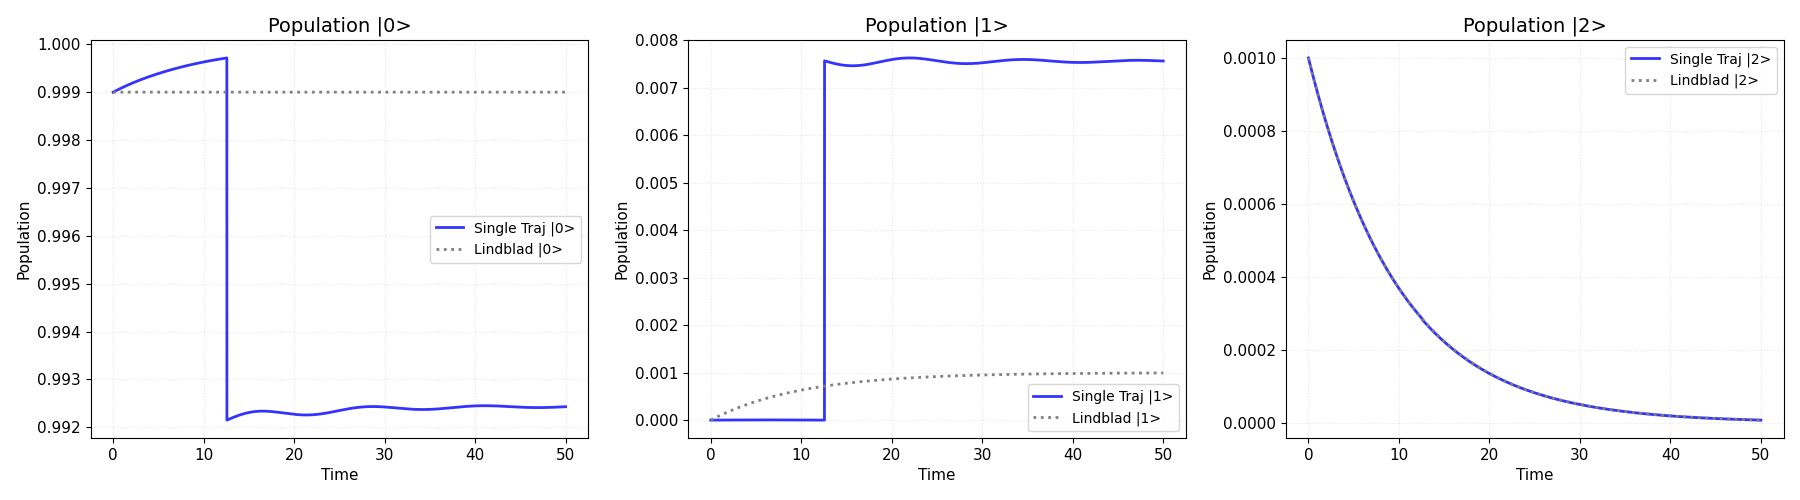

In [8]:
# ========================================================
# Plot 2: Comparison trajectories Collisional vs Lindblad
# ========================================================

sample_idx = jump_indices[3] 
# sample_idx = 978 

plot_data_single = [
    {'single': pop_00[:, sample_idx], 'lindblad': lindblad_00, 'label': '|0>'},
    {'single': pop_11[:, sample_idx], 'lindblad': lindblad_11, 'label': '|1>'},
    {'single': pop_22[:, sample_idx], 'lindblad': lindblad_22, 'label': '|2>'}
]

fig02, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, data_s in zip(axes, plot_data_single):
    lbl = data_s['label']
    ax.plot(times, data_s['single'], label=f'Single Traj {lbl}', linewidth=2, alpha=0.8, color='blue')
    ax.plot(times, data_s['lindblad'], label=f'Lindblad {lbl}', linewidth=2, linestyle=':', color='gray')

    ax.set_title(f'Population {lbl}', fontsize=14)
    ax.set_xlabel('Time')
    ax.set_ylabel('Population')

    formatter = ticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False) 
    ax.yaxis.set_major_formatter(formatter)
    ax.legend(loc='best')

# fig02.suptitle(f'Angle {theta_deg}° - Single Trajectory vs Lindblad (Sample: {sample_idx})', fontsize=15)
# save_fig(fig02, f'Single_Traj_vs_Lindblad_Theta_{float(theta_deg):.4f}'.replace('.', 'p'))

plt.show()

In [39]:
a = times[pop_11[:, sample_idx] > 0.007][0]


In [40]:
total_jumps[times==a]

array([1])

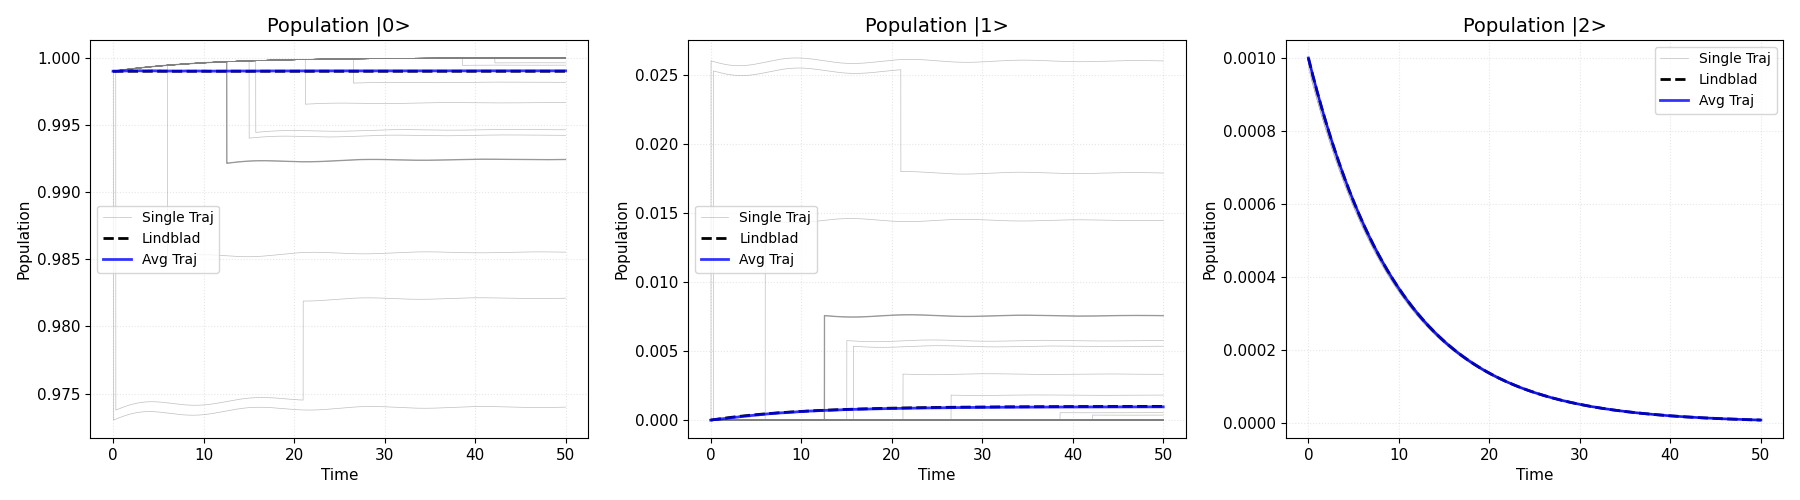

In [9]:
# ======================================================
# Plot 3: Many Single Trajectories vs Average vs Lindblad
# ======================================================
num_samples = 50 

plot_data_many = [
    {'samples': pop_00[:, :num_samples], 'lindblad': lindblad_00, 'avg': avg_pop_00, 'jump': pop_00[:, sample_idx], 'label': '|0>'},
    {'samples': pop_11[:, :num_samples], 'lindblad': lindblad_11, 'avg': avg_pop_11, 'jump': pop_11[:, sample_idx], 'label': '|1>'},
    {'samples': pop_22[:, :num_samples], 'lindblad': lindblad_22, 'avg': avg_pop_22, 'jump': pop_22[:, sample_idx], 'label': '|2>'}
]

fig03, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, data_m in zip(axes, plot_data_many):
    lbl = data_m['label']

    for i in range(num_samples):
        ax.plot(times, data_m['samples'][:, i], color='gray', alpha=0.50, linewidth=0.5, 
                label='Single Traj' if i == 0 else "")

    if len(jump_indices) > 0:
        ax.plot(times, data_m['jump'], color='gray', alpha=0.70, linewidth=1, label="")

    ax.plot(times, data_m['lindblad'], label='Lindblad', linewidth=2, linestyle='--', color='black')
    ax.plot(times, data_m['avg'], label='Avg Traj', linewidth=2, color='blue', alpha=0.8)

    ax.set_title(f'Population {lbl}', fontsize=14)
    ax.set_xlabel('Time')
    ax.set_ylabel('Population')

    formatter = ticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False) 
    ax.yaxis.set_major_formatter(formatter)
    ax.legend(loc='best', fontsize=10)

plt.show()

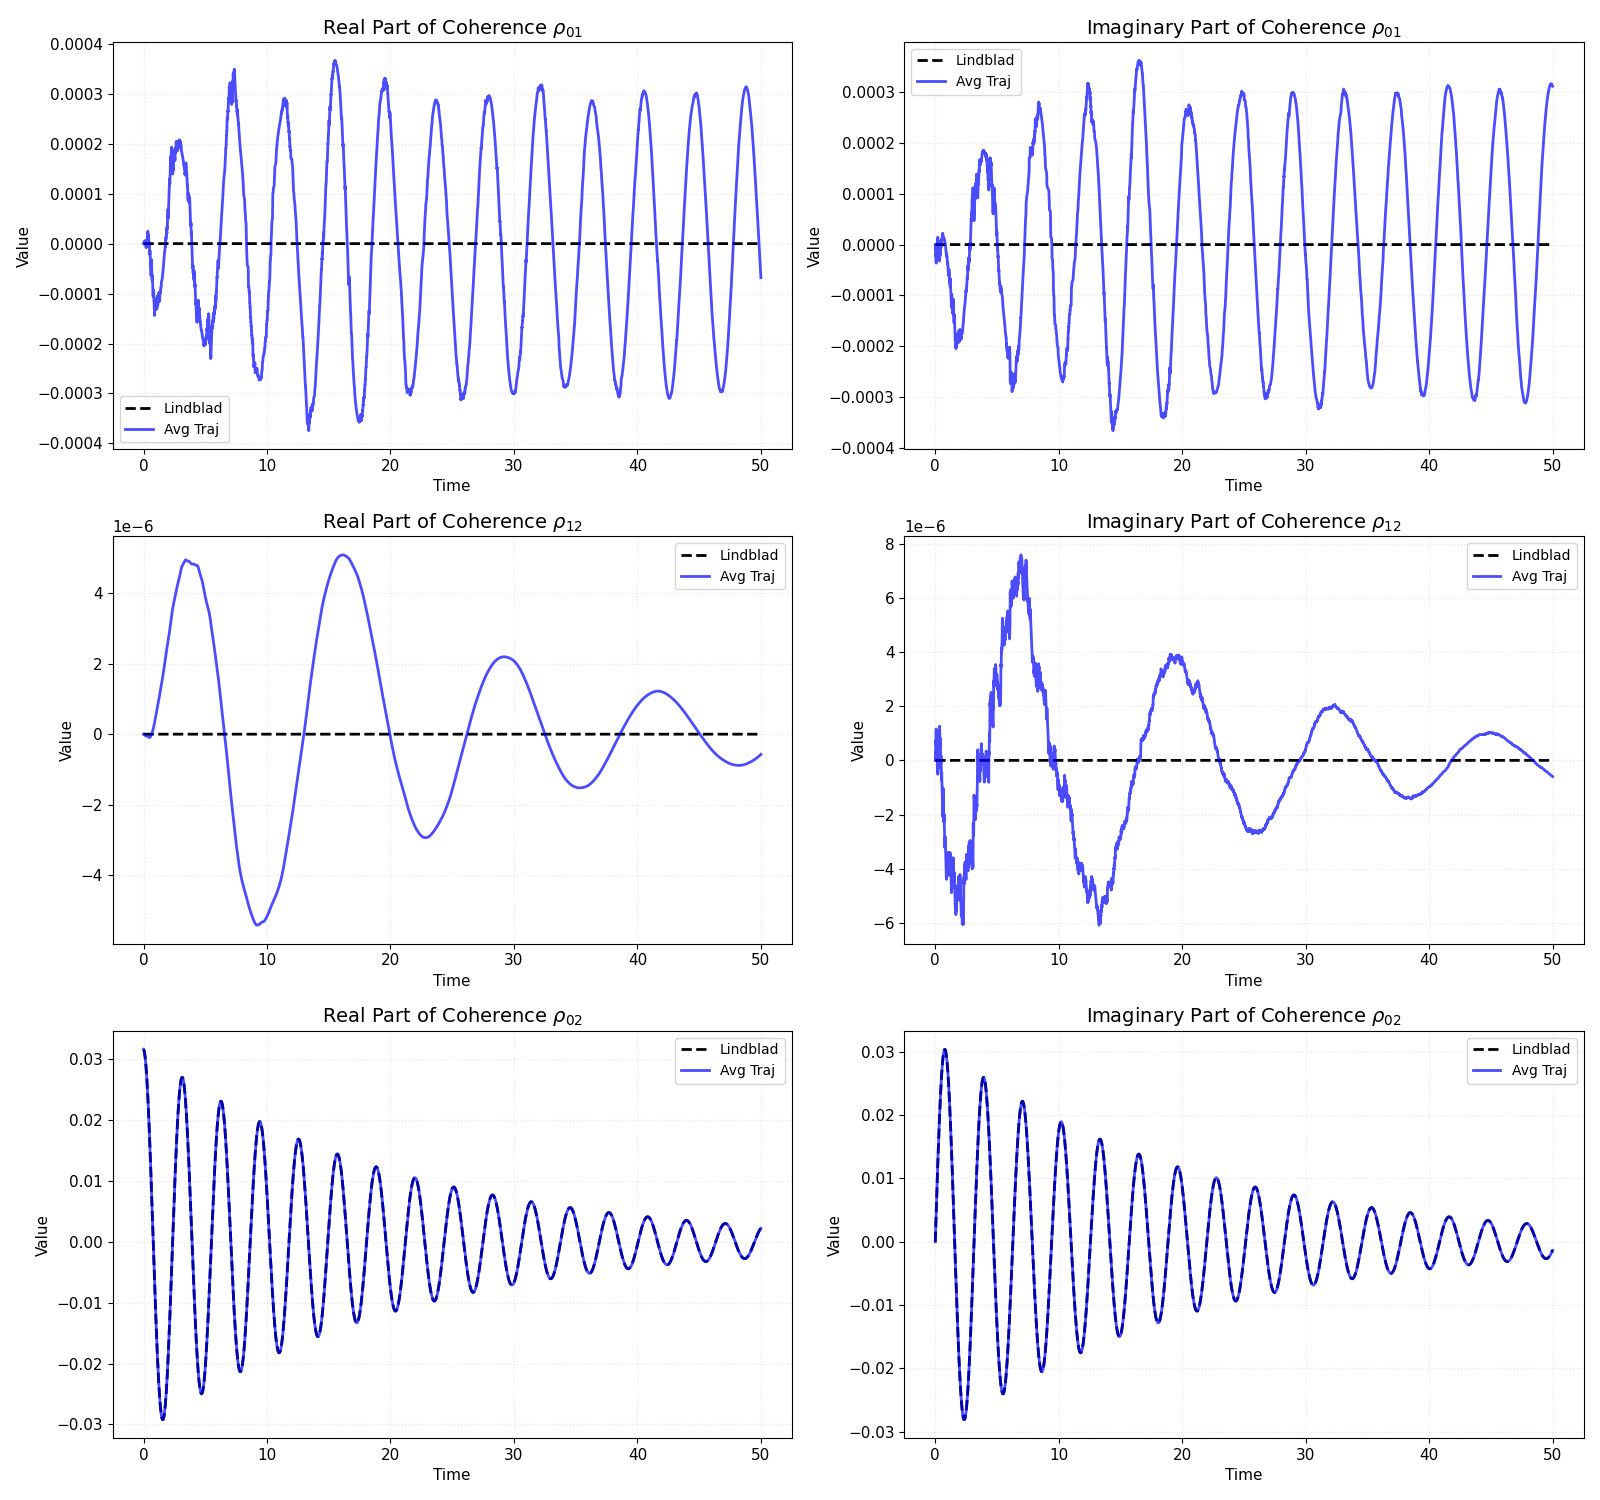

In [10]:
# =========================================================
# Plot 4: Plotting Real and Imaginary Coherences
# =========================================================
coherence_data = [
    ('01', lindblad_01, avg_coh_01),
    ('12', lindblad_12, avg_coh_12),
    ('02', lindblad_02, avg_coh_02)
]

fig04, axes = plt.subplots(3, 2, figsize=(16, 15))

for row_idx, (label, lind_data, avg_data) in enumerate(coherence_data):
    # Real Part
    ax_real = axes[row_idx, 0]
    ax_real.plot(times, np.real(lind_data), label=f'Lindblad', linewidth=2, linestyle='--', color='black')
    ax_real.plot(times, np.real(avg_data), label=f'Avg Traj', linewidth=2, color='blue', alpha=0.7)
    ax_real.set_title(f'Real Part of Coherence $\\rho_{{{label}}}$', fontsize=14)

    # Imaginary Part
    ax_imag = axes[row_idx, 1]
    ax_imag.plot(times, np.imag(lind_data), label=f'Lindblad', linewidth=2, linestyle='--', color='black')
    ax_imag.plot(times, np.imag(avg_data), label=f'Avg Traj', linewidth=2, color='blue', alpha=0.7)
    ax_imag.set_title(f'Imaginary Part of Coherence $\\rho_{{{label}}}$', fontsize=14)

for ax in axes.flat:
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend(loc='best')
    formatter = ticker.ScalarFormatter(useOffset=False)
    ax.yaxis.set_major_formatter(formatter)
    
plt.show()

In [ ]:
# =========================================================
# Plot 5 & 6: No-Jump Post-Selected Subensemble
# =========================================================
N_traj_total = pop_00.shape[1]
all_indices = np.arange(N_traj_total)
no_jump_indices = np.setdiff1d(all_indices, jump_indices)

if len(no_jump_indices) > 0:
    # Populations (Averaging only over the 'no_jump_indices')
    avg_pop_00_nj = pop_00[:, no_jump_indices].mean(axis=1)
    avg_pop_11_nj = pop_11[:, no_jump_indices].mean(axis=1)
    avg_pop_22_nj = pop_22[:, no_jump_indices].mean(axis=1)

    # Coherences
    avg_coh_01_nj = coh_01[:, no_jump_indices].mean(axis=1)
    avg_coh_12_nj = coh_12[:, no_jump_indices].mean(axis=1)
    avg_coh_02_nj = coh_02[:, no_jump_indices].mean(axis=1)

    # --- Plot Populations (No-Jump) ---
    fig_pop, axes_pop = plt.subplots(1, 3, figsize=(18, 5))
    pop_data_nj = [
        {'lindblad': lindblad_00, 'full_avg': avg_pop_00, 'no_jump': avg_pop_00_nj, 'label': '|0>'},
        {'lindblad': lindblad_11, 'full_avg': avg_pop_11, 'no_jump': avg_pop_11_nj, 'label': '|1>'},
        {'lindblad': lindblad_22, 'full_avg': avg_pop_22, 'no_jump': avg_pop_22_nj, 'label': '|2>'}
    ]

    for ax, data_nj in zip(axes_pop, pop_data_nj):
        lbl = data_nj['label']
        ax.plot(times, data_nj['lindblad'], label='Lindblad', linewidth=2, linestyle='--', color='black')
        ax.plot(times, data_nj['full_avg'], label='Standard Avg', linewidth=2, color='blue', alpha=0.3)
        ax.plot(times, data_nj['no_jump'], label='No-Jump Evolution', linewidth=2.5, color='red', alpha=0.9)
        
        ax.set_title(f'Population {lbl}', fontsize=14)
        ax.set_xlabel('Time')
        ax.legend(loc='best')

    # fig_pop.suptitle(f'Angle {theta_deg}° Populations: Post-Selected Subensemble (No Jumps)', fontsize=16)
    # save_fig(fig_pop, f'NO_JUMPS_Populations_Theta_{float(theta_deg):.4f}'.replace('.', 'p'))

    # --- Plot Coherences (No-Jump) ---
    fig_coh, axes_coh = plt.subplots(3, 2, figsize=(16, 15))
    coh_data_nj = [
        ('01', lindblad_01, avg_coh_01, avg_coh_01_nj),
        ('12', lindblad_12, avg_coh_12, avg_coh_12_nj),
        ('02', lindblad_02, avg_coh_02, avg_coh_02_nj)
    ]

    for row_idx, (label, lind_data, full_avg, no_jump_avg) in enumerate(coh_data_nj):
        # Real Part
        ax_real = axes_coh[row_idx, 0]
        ax_real.plot(times, np.real(lind_data), label='Lindblad', linestyle='--', color='black')
        ax_real.plot(times, np.real(full_avg), label='Standard Avg', color='blue', alpha=0.3)
        ax_real.plot(times, np.real(no_jump_avg), label='No-Jump', linewidth=2.5, color='red', alpha=0.9)
        ax_real.set_title(f'Real Part $\\rho_{{{label}}}$')

        # Imaginary Part
        ax_imag = axes_coh[row_idx, 1]
        ax_imag.plot(times, np.imag(lind_data), label='Lindblad', linestyle='--', color='black')
        ax_imag.plot(times, np.imag(full_avg), label='Standard Avg', color='blue', alpha=0.3)
        ax_imag.plot(times, np.imag(no_jump_avg), label='No-Jump', linewidth=2.5, color='red', alpha=0.9)
        ax_imag.set_title(f'Imaginary Part $\\rho_{{{label}}}$')

    for ax in axes_coh.flat:
        ax.legend(loc='best')

    plt.show()